In [1]:
import numpy as np
from itertools import chain

from response_stats.generators import PoissonSpikeGenerator
from response_stats.responses import ResponseConfig, make_response_data, ResponseDetector
from response_stats.responses.response_tests import WilcoxonTest, SurrogateTest

from response_stats.plot_utils import *

Baseline duration: 1 s
Mean, baseline: 7.35 Hz
Response duration, edge-corrected: 1.0000000000000009 s
Mean, response: 7.163157894736842 Hz


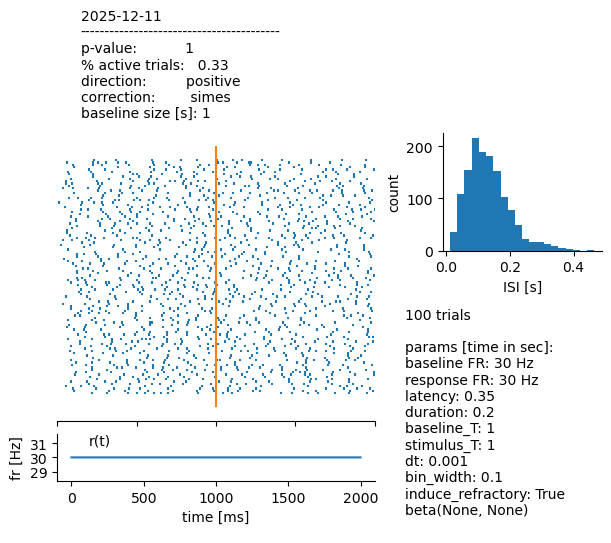

(<Figure size 600x400 with 4 Axes>,
 {'raster': <Axes: label='raster'>,
  'isi': <Axes: label='isi', xlabel='ISI [s]', ylabel='count'>,
  'text': <Axes: label='text'>,
  'r_t': <Axes: label='r_t', xlabel='time [ms]', ylabel='fr [Hz]'>})

In [2]:
baseline_fr = 30
response_fr = 30
latency = 0.35
duration = 0.2
dt = 0.001
baseline_T = 1
stimulus_T = 1

total_bins = int((baseline_T + stimulus_T) / dt)

induce_refractory_period = True

n_trials = 100

generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period,
    
)

trial_activity = generator.generate(n_trials)

cfg_response_dict = {
    "trial_activity": trial_activity,
    "baseline_T": baseline_T,
    "stimulus_T": stimulus_T,
    "stimulus_onset": baseline_T,
    "bin_width": 0.1,
    "dt": dt,
    "direction": "positive",
    "proportion_active": 1/3,
    "multiple_correction": "simes",
    "interleave_response_bins": True,
    "smooth_response_bins": False,
    "debug": True,
}

cfg_response = ResponseConfig(**cfg_response_dict)
data_response = make_response_data(cfg_response)

detector = ResponseDetector(data_response, WilcoxonTest)

SpikeSummaryFigure(trial_activity, generator, detector, ).build()

In [3]:
cfg_response_dict = {
    "trial_activity": trial_activity,
    "baseline_T": baseline_T,
    "stimulus_T": stimulus_T,
    "stimulus_onset": baseline_T,
    "bin_width": 0.1,
    "dt": dt,
    "direction": "positive",
    "proportion_active": 1/3,
    "multiple_correction": "simes",
    "interleave_response_bins": False,
    "smooth_response_bins": False,
    "debug": True,
}

cfg_response = ResponseConfig(**cfg_response_dict)
data_response = make_response_data(cfg_response)

detector = ResponseDetector(data_response, SurrogateTest, n_perms=100)
detector.compute_min_pval()

Baseline duration: 1 s
Mean, baseline: 7.35 Hz
Response duration, edge-corrected: 1.0000000000000009 s
Mean, response: 7.2 Hz


np.float64(0.009900990099009901)

In [5]:
detector.test.permuted_tstats

array([3.09875002e-40, 4.58023638e-42, 1.05233758e-39, 6.11317317e-42,
       3.23104254e-48, 5.14209572e-40, 6.47216104e-42, 2.75347252e-39,
       1.04101383e-41, 4.32949518e-41, 2.53851445e-44, 1.68751631e-40,
       1.05686846e-39, 5.37572279e-45, 2.03693554e-40, 3.14933344e-42,
       6.39464542e-42, 6.71672657e-39, 7.32982016e-43, 1.87950282e-44,
       3.39148250e-38, 1.93544593e-46, 8.39738136e-39, 1.33353706e-45,
       5.85949008e-38, 5.64138365e-43, 2.42907186e-41, 1.03816036e-40,
       1.29972487e-44, 1.71715426e-41, 2.08760619e-39, 4.86035715e-40,
       4.48492945e-40, 8.61957710e-42, 1.07368143e-39, 1.08564561e-46,
       1.16727500e-44, 6.12744948e-39, 1.85050285e-45, 3.44348326e-41,
       2.53165060e-40, 2.05705412e-46, 1.12478433e-42, 1.30687035e-39,
       7.25639193e-39, 3.18777993e-38, 1.28628167e-40, 9.88627087e-41,
       1.09920131e-43, 2.54216680e-40, 1.33353706e-45, 5.08953181e-44,
       1.11902199e-39, 3.05510065e-47, 2.81114864e-43, 1.47426555e-39,
      

In [ ]:
n_perms = 100
surrogates = detector.test.construct_surrogates(data_response)

bins_whole_trial = detector.test._get_whole_trial_bins(data_response)

permuted_tstats = np.ones(detector.test.n_perms)
baseline_ind = np.where(bins_whole_trial == data_response.cfg.baseline_T)[0][0]

assert baseline_ind / (len(bins_whole_trial) - 1) == data_response.cfg.baseline_T / (data_response.cfg.baseline_T + data_response.cfg.stimulus_T), f"Slice for the baseline index doesn't make sense."

for n, s in enumerate(surrogates):
    # slice the surrogate response into baseline and response periods
    b_hist = s[:, 0:baseline_ind]
    r_hist = s[:, baseline_ind:]
    assert b_hist.shape[1] + r_hist.shape[1] == len(bins_whole_trial) - 1

    b_1_second = np.sum(b_hist, axis=1)

    b_tstats, _ = detector.test.binwise_test(b_1_second, r_hist)
    permuted_tstats[n] = np.max(b_tstats)
    

In [13]:
x

(array([-19.76013375, -19.9137062 , -19.9137062 , -20.0716387 ,
        -20.0716387 , -19.76013375, -19.61081184, -19.76013375,
        -19.52959049, -19.76013375, -19.76013375, -19.61081184,
        -19.9137062 , -19.76013375, -19.76013375, -20.0716387 ,
        -20.0716387 , -20.0716387 , -19.8310935 , -19.9137062 ]),
 array([3.11224565e-39, 1.53850916e-39, 1.53850916e-39, 7.47792255e-40,
        7.47792255e-40, 3.11224565e-39, 6.19176842e-39, 3.11224565e-39,
        9.01202854e-39, 3.11224565e-39, 3.11224565e-39, 6.19176842e-39,
        1.53850916e-39, 3.11224565e-39, 3.11224565e-39, 7.47792255e-40,
        7.47792255e-40, 7.47792255e-40, 2.24665030e-39, 1.53850916e-39]))

(array([10., 17.,  0., 28.,  0., 24., 15.,  0.,  4.,  2.]),
 array([ 5. ,  5.6,  6.2,  6.8,  7.4,  8. ,  8.6,  9.2,  9.8, 10.4, 11. ]),
 <BarContainer object of 10 artists>)

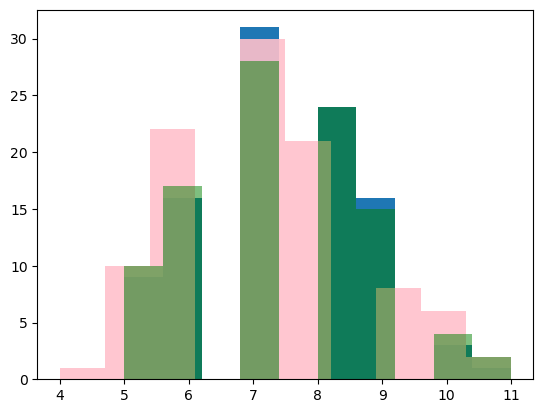

In [41]:
plt.hist(data_response.baseline_hist)
plt.hist(b_1_second, color="pink", alpha=0.9)
plt.hist(np.sum(r_hist, axis=1), color="green", alpha=0.5)

In [10]:
data_response.baseline_hist

array([ 9.,  7.,  8.,  6.,  7.,  7.,  8.,  7.,  7.,  7.,  7.,  8.,  9.,
        7.,  8.,  5.,  5.,  6.,  7.,  8.,  7.,  9.,  6., 11.,  5.,  9.,
        7.,  7.,  7.,  8.,  7.,  8.,  5.,  6.,  9.,  8.,  8.,  8.,  7.,
        5.,  8.,  7.,  7.,  7., 10.,  8.,  9., 10.,  8.,  8.,  6.,  6.,
        7.,  8.,  7.,  8.,  8.,  7.,  8.,  7.,  6.,  5.,  6.,  7.,  7.,
        9.,  9.,  5.,  7.,  6.,  6.,  8.,  9.,  7.,  8.,  8.,  6.,  7.,
        9.,  9.,  6.,  8., 10.,  9.,  5.,  7.,  7.,  9.,  7.,  9.,  9.,
        6.,  6.,  7.,  8.,  6.,  6.,  9.,  8.,  5.])

In [ ]:
data_response.response_hist.shape

(100, 10)

In [17]:
empirical_tstat = detector.test.compute_empirical_tstat(data_response)
print(empirical_tstat)

0.6499642765715703


In [20]:
permuted_tstats

array([3.43250093e-47, 3.81989591e-40, 1.68107709e-38, 3.45179450e-40,
       6.34734526e-43, 6.04815203e-41, 4.32164806e-46, 6.45739779e-43,
       1.52231122e-39, 2.55470492e-39, 5.24913237e-37, 3.95652414e-40,
       4.21540857e-42, 1.37320112e-40, 3.86213819e-44, 6.60530023e-42,
       6.92953466e-46, 1.78052877e-42, 4.60528676e-43, 9.97523187e-42,
       1.55227557e-42, 1.68992193e-41, 1.53128602e-47, 1.94514037e-40,
       4.21540857e-42, 4.08611496e-45, 3.41514780e-41, 3.22748187e-43,
       5.00535446e-40, 2.83905329e-43, 1.94514037e-40, 1.65164962e-43,
       1.63827196e-42, 2.44929735e-41, 3.76084480e-40, 1.16632567e-42,
       7.73141500e-42, 6.76973461e-46, 3.51769565e-40, 2.32537568e-40,
       6.45264906e-45, 1.33433068e-40, 4.37802542e-42, 8.53674991e-39,
       3.07901032e-43, 2.93268619e-43, 6.95451520e-44, 2.87195668e-43,
       1.75805301e-43, 8.48208738e-41, 2.96598572e-42, 9.87357677e-44,
       8.55131567e-40, 8.66547218e-41, 2.38914641e-39, 5.14703065e-39,
      

(array([97.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  1.]),
 array([1.53128602e-47, 1.03706614e-37, 2.07413228e-37, 3.11119843e-37,
        4.14826457e-37, 5.18533071e-37, 6.22239685e-37, 7.25946299e-37,
        8.29652914e-37, 9.33359528e-37, 1.03706614e-36]),
 <BarContainer object of 10 artists>)

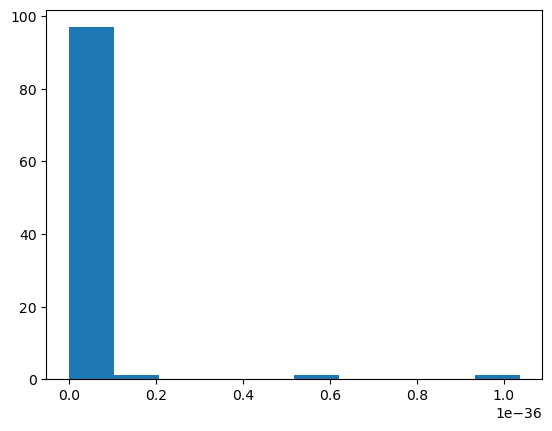

In [21]:
plt.hist(permuted_tstats)
#plt.vlines(empirical_tstat, 0, 80, color="red")